# Predictive Maintenance Classification Project

Bu projede Kaggle üzerinde bulunan Predictive Maintenance veri seti kullanılmıştır.

Amaç, makine sensör verilerine bakarak bir makinede arıza oluşup oluşmayacağını tahmin etmektir.

Hedef değişken `Target` sütunudur:

- `0`: Arıza yok
- `1`: Arıza var

Bu çalışmada farklı makine öğrenmesi modelleri eğitilmiş ve performansları karşılaştırılmıştır.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 1. Dataset Loading and Initial Inspection

Bu bölümde veri seti okunmuş ve ilk satırlar incelenmiştir. Ayrıca veri setinin satır ve sütun sayısı kontrol edilmiştir.

In [77]:
df = pd.read_csv("../data/predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [78]:
df.shape

(10000, 10)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [80]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

## 2. Data Preprocessing

Bu bölümde makine öğrenmesi modeli için gereksiz sütunlar kaldırılmıştır.

- UDI
- Product ID
- Failure Type

Ayrıca Type sütunu sayısal değerlere dönüştürülmüştür.

- L → 0
- M → 1
- H → 2

In [81]:
df["Type"] = df["Type"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,No Failure


In [82]:
df_model = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Failure Type"
    ]
)

df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


## 3. Feature and Target Separation

Bu aşamada bağımsız değişkenler (X) ve hedef değişken (y) ayrılmıştır.

Target sütunu tahmin edilmek istenen değişkendir.

In [83]:
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 6)
Target Shape: (10000,)


In [84]:
y.value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [85]:
y.value_counts(normalize=True) * 100

Target
0    96.61
1     3.39
Name: proportion, dtype: float64

## 4. Train-Test Split

Veri seti eğitim ve test olmak üzere iki parçaya ayrılmıştır.

- %80 Eğitim Verisi
- %20 Test Verisi

Ayrıca veri seti dengesiz olduğu için `stratify=y` kullanılmıştır.

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)

Training Set: (8000, 6)
Test Set: (2000, 6)


## 5. Logistic Regression

Logistic Regression sınıflandırma problemlerinde kullanılan temel ve yorumlanabilir bir algoritmadır.

Bu çalışmada diğer modeller için bir referans noktası oluşturması amacıyla kullanılmıştır.

In [87]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [88]:
print("Accuracy:",
      accuracy_score(y_test, lr_predictions))

Accuracy: 0.9675


In [89]:
print(confusion_matrix(
    y_test,
    lr_predictions
))

[[1928    4]
 [  61    7]]


In [90]:
print(classification_report(
    y_test,
    lr_predictions
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



### Logistic Regression Evaluation

Accuracy, Precision, Recall ve F1-Score değerleri incelenmiştir.

Özellikle arızalı makineleri temsil eden sınıfın (Target=1) recall değeri değerlendirilmiştir.

## 6. Decision Tree

Decision Tree modeli karar kuralları oluşturarak sınıflandırma yapar.

Bu modelin avantajı yorumlanabilir olmasıdır. Hangi özelliklerin karar vermede etkili olduğu daha kolay anlaşılabilir.

In [91]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_predictions = dt_model.predict(
    X_test
)

In [92]:
print("Accuracy:",
      accuracy_score(
          y_test,
          dt_predictions
      ))

Accuracy: 0.9775


In [93]:
print(confusion_matrix(
    y_test,
    dt_predictions
))

[[1909   23]
 [  22   46]]


In [94]:
print(classification_report(
    y_test,
    dt_predictions
))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.67      0.68      0.67        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000



### Decision Tree Evaluation

Decision Tree modeli Logistic Regression ile karşılaştırılmıştır.

Özellikle arızalı makineleri tespit etme başarısı (Recall) değerlendirilmiştir.

## 7. Random Forest

Random Forest, birden fazla karar ağacının birleşiminden oluşan bir ensemble öğrenme yöntemidir.

Tek bir karar ağacına göre daha kararlı sonuçlar üretmesi beklenmektedir.

In [95]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

In [96]:
print("Accuracy:",
      accuracy_score(
          y_test,
          rf_predictions
      ))

Accuracy: 0.984


In [97]:
print(confusion_matrix(
    y_test,
    rf_predictions
))

[[1926    6]
 [  26   42]]


In [98]:
print(classification_report(
    y_test,
    rf_predictions
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.62      0.72        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



### Random Forest Evaluation

Random Forest modeli birden fazla karar ağacını birleştirerek daha güçlü tahminler üretmektedir.

Accuracy, Precision, Recall ve F1-Score değerleri değerlendirilmiştir.

## 8. Balanced Random Forest

Veri setinde arızalı örneklerin oranı oldukça düşüktür.

Bu nedenle sınıf dengesizliğinin etkisini azaltmak amacıyla class_weight="balanced" parametresi kullanılmıştır.

In [99]:
balanced_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

balanced_rf_model.fit(
    X_train,
    y_train
)

balanced_rf_predictions = balanced_rf_model.predict(
    X_test
)

In [100]:
print("Accuracy:",
      accuracy_score(
          y_test,
          balanced_rf_predictions
      ))

Accuracy: 0.9825


In [101]:
print(confusion_matrix(
    y_test,
    balanced_rf_predictions
))

[[1927    5]
 [  30   38]]


In [102]:
print(classification_report(
    y_test,
    balanced_rf_predictions
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.56      0.68        68

    accuracy                           0.98      2000
   macro avg       0.93      0.78      0.84      2000
weighted avg       0.98      0.98      0.98      2000



## 9. Gradient Boosting

Gradient Boosting, zayıf karar ağaçlarını ardışık şekilde eğiterek hataları azaltmaya çalışan güçlü bir ensemble öğrenme yöntemidir.

Bu model Random Forest ile karşılaştırmak amacıyla kullanılmıştır.

In [103]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(
    X_test
)

In [104]:
print("Accuracy:",
      accuracy_score(
          y_test,
          gb_predictions
      ))

Accuracy: 0.9865


In [105]:
print(confusion_matrix(
    y_test,
    gb_predictions
))

[[1926    6]
 [  21   47]]


In [106]:
print(classification_report(
    y_test,
    gb_predictions
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.94      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



## 10. Model Comparison

Bu bölümde tüm modellerin başarı sonuçları karşılaştırılmıştır.

In [107]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, balanced_rf_predictions),
        accuracy_score(y_test, gb_predictions)
    ],
    "Recall":[
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, balanced_rf_predictions),
        recall_score(y_test, gb_predictions)
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Recall
4,Gradient Boosting,0.9865,0.691176
2,Random Forest,0.9840,0.617647
3,Balanced Random Forest,0.9825,0.558824
1,Decision Tree,0.9775,0.676471
0,Logistic Regression,0.9675,0.102941


## 11. Feature Importance Analysis

Random Forest modeli kullanılarak hangi özelliklerin tahmin üzerinde daha etkili olduğu incelenmiştir.

In [108]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Torque [Nm],0.330107
3,Rotational speed [rpm],0.223828
5,Tool wear [min],0.164423
1,Air temperature [K],0.130418
2,Process temperature [K],0.127177
0,Type,0.024047


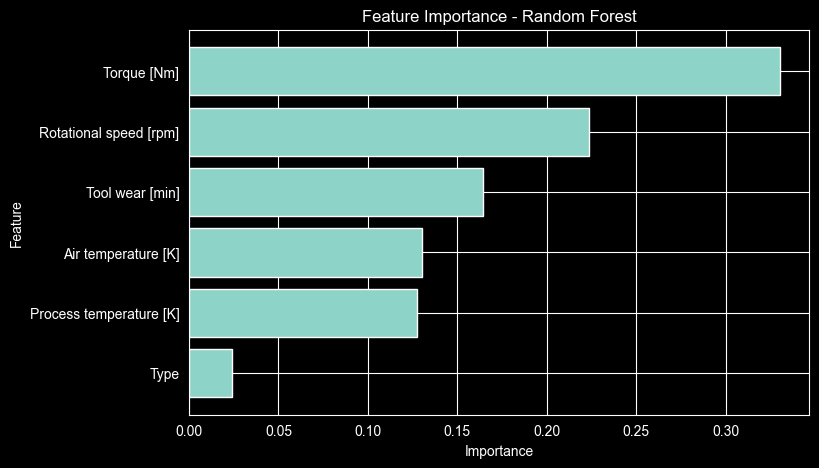

In [109]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()

# 12. Conclusion

Bu çalışmada Predictive Maintenance veri seti üzerinde farklı makine öğrenmesi algoritmaları uygulanmıştır.

Kullanılan modeller:

- Logistic Regression
- Decision Tree
- Random Forest
- Balanced Random Forest
- Gradient Boosting

Sonuçlar incelendiğinde Random Forest ve Gradient Boosting modellerinin en başarılı sonuçları verdiği gözlemlenmiştir.

Veri setinin dengesiz yapısı nedeniyle sadece accuracy değeri değil, recall ve F1-score değerleri de değerlendirilmiştir.

Makine arızalarının erken tespiti açısından özellikle arızalı sınıfın recall değeri önemli kabul edilmiştir.